In [ ]:
# load all .npz files from the raw/ directory
# Each .npz file contains an array of (t_id, 26) list in the "actions" key, and a scalar frequency information in the "num_strikes" key
# Load all .npz files and these keys first
import numpy as np
from pathlib import Path


trajectories = []
frequencies = []
for npz_file in Path("raw").glob("*.npz"):
    data = np.load(npz_file)
    trajectories.append(data["actions"])
    frequencies.append(data["num_strikes"].item())


In [2]:
print(frequencies)
min_len = 1000
for i in range(len(trajectories)):
    print(trajectories[i].shape)
    min_len = min(min_len, trajectories[i].shape[0])

[3, 4, 4, 3, 5, 5, 6, 6, 4, 6, 3, 3, 4, 6, 5, 5, 6]
(90, 26)
(120, 26)
(120, 26)
(90, 26)
(150, 26)
(150, 26)
(180, 26)
(180, 26)
(120, 26)
(180, 26)
(90, 26)
(90, 26)
(120, 26)
(180, 26)
(150, 26)
(150, 26)
(180, 26)


In [3]:
# Donwsample all trajectories to the same length (min_len) using linear interpolation
downsampled_trajectories = []
max_freq = max(frequencies)
for traj in trajectories:
    downsampled_traj = np.zeros((min_len, traj.shape[1]), dtype=np.float32)
    for i in range(traj.shape[1]):
        downsampled_traj[:, i] = np.interp(np.linspace(0, traj.shape[0] - 1, min_len), np.arange(traj.shape[0]), traj[:, i])
    downsampled_trajectories.append(downsampled_traj)


In [ ]:
# For each different frequency value, here are 4 downsampled_trajectories. Use 3 out of 4 to
# Create x.pt: time between 0-1, y.pt: the 26-dim trajectory, and g.pt: the frequency information
# Use the remaining one to create x_test.pt, y_test.pt, g_test.pt

num_train, num_test = len(trajectories) - len(set(frequencies)), len(set(frequencies))
t_steps = min_len

x = []
y = []
g = []
x_test = []
y_test = []
g_test = []
for freq in set(frequencies):
    indices = [i for i, f in enumerate(frequencies) if f == freq]
    # Use the first 3 trajectories for training, and the last one for testing
    for i in indices[:-1]:
        x.append(np.linspace(0, 1, t_steps).reshape(-1, 1))
        y.append(downsampled_trajectories[i])
        g.append(freq/max_freq)  # Normalize frequency to [0, 1]
    x_test.append(np.linspace(0, 1, t_steps).reshape(-1, 1))
    y_test.append(downsampled_trajectories[indices[-1]])
    g_test.append(freq/max_freq)  # Normalize frequency to [0, 1]

x = np.array(x, dtype=np.float32)
y = np.array(y, dtype=np.float32)
g = np.array(g, dtype=np.float32)
x_test = np.array(x_test, dtype=np.float32)
y_test = np.array(y_test, dtype=np.float32)
g_test = np.array(g_test, dtype=np.float32)

# Save these as .npy files
np.save(f"processed/x.npy", x)
np.save(f"processed/y.npy", y)
np.save(f"processed/g.npy", g)
np.save(f"processed/x_test.npy", x_test)
np.save(f"processed/y_test.npy", y_test)
np.save(f"processed/g_test.npy", g_test)

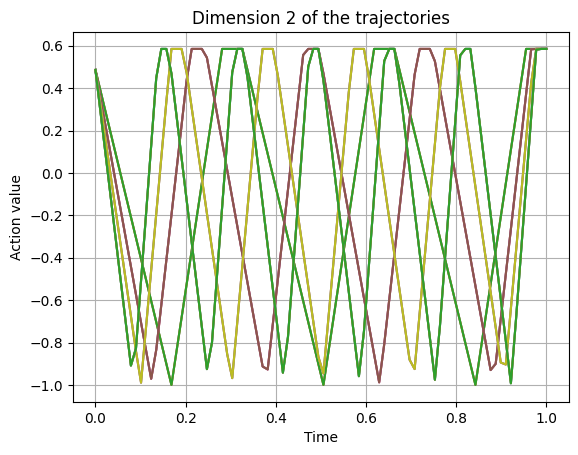

In [32]:
# Plot one diemension of the trajectories to verify
import matplotlib.pyplot as plt
dim = 2
for i in range(len(x)):
    # if g[i] == 5:  # Only plot trajectories with frequency 1 for clarity
    plt.plot(x[i], y[i][:, dim], label=f"Train - freq {g[i]}")
# for i in range(len(x_test)):
    # plt.plot(x_test[i], y_test[i][:, dim], label=f"Test - freq {g_test[i]}")

plt.grid()  # Add grid for better visibility
# plt.legend()
plt.title(f"Dimension {dim} of the trajectories")
plt.xlabel("Time")
plt.ylabel("Action value")
plt.show()


In [33]:
print(g)
print(g_test)

[0.5       0.5       0.5       0.6666667 0.6666667 0.6666667 0.8333333
 0.8333333 0.8333333 1.        1.        1.        1.       ]
[0.5       0.6666667 0.8333333 1.       ]
